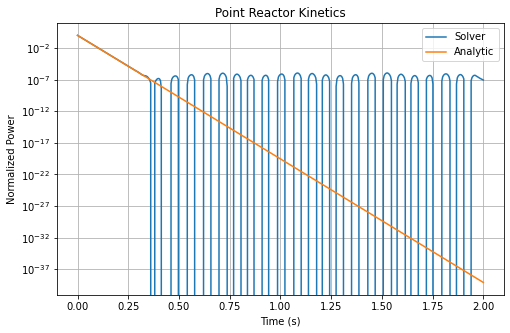

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
rho = 0.002
beta = 0.0065
Lambda = 1e-4

def kinetics(t, P):

    dPdt = ((rho-beta)/Lambda)*P

    return dPdt

sol = solve_ivp(
    kinetics,
    [0,2],
    [1],
    t_eval=np.linspace(0,2,500)
)

P_analytic = np.exp(
    ((0.002-beta)/Lambda)
    * sol.t
)

plt.figure(figsize=(8,5))

plt.plot(
    sol.t,
    sol.y[0],label="Solver"
)
plt.plot(
    sol.t,
    P_analytic,label="Analytic"
)
plt.yscale("log")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Power")
plt.title("Point Reactor Kinetics")
plt.legend()
plt.grid(True)
plt.savefig(
    "reactor_kinetics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [12]:
reactivities = [ -0.002, 0.000, 0.002, 0.004, 0.008]

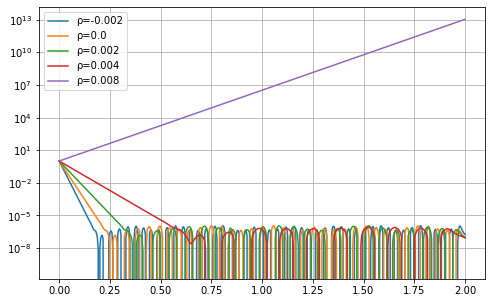

In [13]:
plt.figure(figsize=(8,5))

for rho in reactivities:

    def kinetics(t,P):
        return ((rho-beta)/Lambda)*P

    sol = solve_ivp(
        kinetics,
        [0,2],
        [1],
        t_eval=np.linspace(0,2,500)
    )

    plt.plot(
        sol.t,
        sol.y[0],
        label=f"ρ={rho}"
    )
plt.yscale("log")
plt.legend()
plt.grid()
plt.savefig(
    "reactor_kinetics_reactivities.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

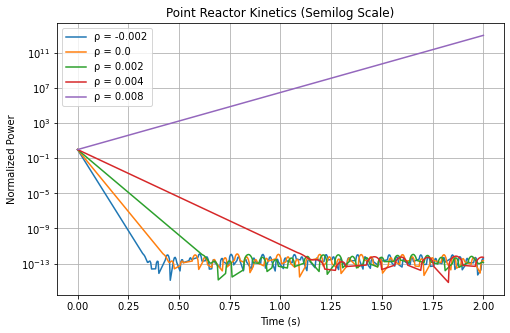

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
beta = 0.0065
Lambda = 1e-4

reactivities = [
    -0.002,
     0.000,
     0.002,
     0.004,
     0.008
]

plt.figure(figsize=(8,5))

for rho in reactivities:

    def kinetics(t, P):
        return ((rho - beta) / Lambda) * P

    sol = solve_ivp(
        kinetics,
        [0, 2],
        [1],
        t_eval=np.linspace(0, 2, 500),
        rtol=1e-10,
        atol=1e-12
    )

    P = sol.y[0]

    # Evita problemas con la escala log
    mask = P > 0

    plt.plot(
        sol.t[mask],
        P[mask],
        label=f"ρ = {rho}"
    )

plt.yscale("log")

plt.xlabel("Time (s)")
plt.ylabel("Normalized Power")
plt.title("Point Reactor Kinetics (Semilog Scale)")
plt.legend()
plt.grid(True)

plt.show()

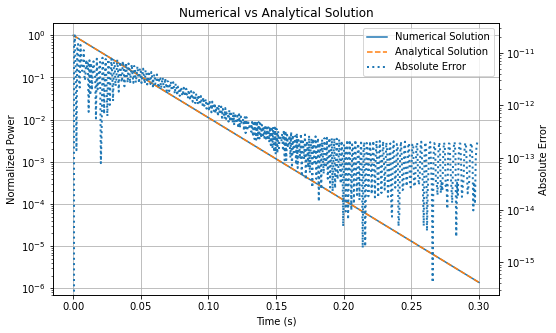

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
rho = 0.002
beta = 0.0065
Lambda = 1e-4

def kinetics(t, P):
    return ((rho - beta) / Lambda) * P

# Numerical solution
sol = solve_ivp(
    kinetics,
    [0, 0.3],  # recomiendo 0.3 s para evitar ruido numérico
    [1],
    t_eval=np.linspace(0, 0.3, 500),
    rtol=1e-10,
    atol=1e-12
)

# Analytical solution
P_analytic = np.exp(
    ((rho - beta) / Lambda) * sol.t
)

# Absolute error
error = np.abs(sol.y[0] - P_analytic)
#Relative error
#error = np.abs(sol.y[0] - P_analytic) / P_analytic
# Figure
fig, ax1 = plt.subplots(figsize=(8,5))

# Power curves
ax1.plot(
    sol.t,
    sol.y[0],
    label="Numerical Solution"
)

ax1.plot(
    sol.t,
    P_analytic,
    "--",
    label="Analytical Solution"
)

ax1.set_yscale("log")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Normalized Power")
ax1.set_title("Numerical vs Analytical Solution")

# Second axis for error
ax2 = ax1.twinx()

ax2.plot(
    sol.t,
    error,
    ":",
    linewidth=2,
    label="Absolute Error"
)

ax2.set_ylabel("Absolute Error")
ax2.set_yscale("log")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

ax1.grid(True)
plt.savefig(
    "validation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [26]:
error = np.max(np.abs(sol.y[0] - P_analytic))

print(f"Maximum error = {error:.2e}")

Maximum error = 2.16e-11
